In [2]:
#import libraries
import pandas as pd
import  numpy as np
import  seaborn as sns
import matplotlib.pyplot as plt
import plotly as plot


In [3]:
df =pd.read_excel("/Users/dersunscheinyn/Downloads/STAT 440 PROJECT/STAT440_GroupC_FinalProject/Dataset/Eight_Databases.xlsx",sheet_name="12_Year_Gasoline")

In [4]:
df.shape

(137, 5)

In [5]:
df.head()

,date,U.S. Gasoline Prices (in cents),OPEC Spot Price: $ per barrel,U.S. Finished Motor Gasoline Production (1000 Barrels per Day),U.S. Natural Gas Wellhead Price ($/1000 Cu.Ft.)
0,1997-01-01,128.3,21.52,7315,3.40
1,1997-02-01,127.6,18.57,7330,2.49
2,1997-03-01,125.1,18.63,7079,1.79
3,1997-04-01,124.4,16.64,7737,1.81
4,1997-05-01,124.5,18.31,7998,2.00


In [6]:
df["U.S. Gasoline Prices (in cents)"].max()

np.float64(381.5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 5 columns):
 #   Column                                                           Non-Null Count  Dtype         
---  ------                                                           --------------  -----         
 0   date                                                             137 non-null    datetime64[ns]
 1   U.S. Gasoline Prices (in cents)                                  137 non-null    float64       
 2   OPEC Spot Price:           $ per barrel                          137 non-null    float64       
 3   U.S. Finished Motor Gasoline Production  (1000 Barrels per Day)  137 non-null    int64         
 4   U.S. Natural Gas Wellhead Price       ($/1000 Cu.Ft.)            137 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 5.5 KB


In [8]:
df.isna().sum()

date                                                               0
U.S. Gasoline Prices (in cents)                                    0
OPEC Spot Price:           $ per barrel                            0
U.S. Finished Motor Gasoline Production  (1000 Barrels per Day)    0
U.S. Natural Gas Wellhead Price       ($/1000 Cu.Ft.)              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,137,2002-08-31 15:45:59.124087552,1997-01-01 00:00:00,1999-11-01 00:00:00,2002-09-01 00:00:00,2005-07-01 00:00:00,2008-05-01 00:00:00,NaN
U.S. Gasoline Prices (in cents),137.0,179.816058,96.2,127.6,155.6,227.5,381.5,66.695284
OPEC Spot Price: $ per barrel,137.0,35.747664,9.56,19.21,26.64,50.29,126.43,23.157659
U.S. Finished Motor Gasoline Production (1000 Barrels per Day),137.0,8444.562044,7079.0,8156.0,8456.0,8779.0,9429.0,465.434346
U.S. Natural Gas Wellhead Price ($/1000 Cu.Ft.),137.0,4.469343,1.7,2.6,4.4,6.06,10.33,2.080828


In [11]:
df["Month"]= df["date"].dt.month_name()

In [12]:
df.head()

,date,U.S. Gasoline Prices (in cents),OPEC Spot Price: $ per barrel,U.S. Finished Motor Gasoline Production (1000 Barrels per Day),U.S. Natural Gas Wellhead Price ($/1000 Cu.Ft.),Month
0,1997-01-01,128.3,21.52,7315,3.40,January
1,1997-02-01,127.6,18.57,7330,2.49,February
2,1997-03-01,125.1,18.63,7079,1.79,March
3,1997-04-01,124.4,16.64,7737,1.81,April
4,1997-05-01,124.5,18.31,7998,2.00,May


In [13]:
df["Year"]= df["date"].dt.year

In [14]:
df["Year"].unique()

array([1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008], dtype=int32)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 7 columns):
 #   Column                                                           Non-Null Count  Dtype         
---  ------                                                           --------------  -----         
 0   date                                                             137 non-null    datetime64[ns]
 1   U.S. Gasoline Prices (in cents)                                  137 non-null    float64       
 2   OPEC Spot Price:           $ per barrel                          137 non-null    float64       
 3   U.S. Finished Motor Gasoline Production  (1000 Barrels per Day)  137 non-null    int64         
 4   U.S. Natural Gas Wellhead Price       ($/1000 Cu.Ft.)            137 non-null    float64       
 5   Month                                                            137 non-null    object        
 6   Year                                                             137 non-null    in

In [16]:
# Convert gasoline price from cents to USD only
df['U.S. Gasoline Prices (in cents)'] = df['U.S. Gasoline Prices (in cents)'] / 100

# Rename all columns to remove spaces and make them clean (snake_case style)
df.rename(columns={
    'date': 'date',
    'U.S. Gasoline Prices (in cents)': 'us_gasoline_price_usd',
    'OPEC Spot Price:           $ per barrel': 'opec_spot_price_usd_per_barrel',
    'U.S. Finished Motor Gasoline Production  (1000 Barrels per Day)': 'us_gasoline_production_1000_bpd',
    'U.S. Natural Gas Wellhead Price       ($/1000 Cu.Ft.)': 'us_natural_gas_price_usd_per_1000_cuft',
    'Month': 'month',
    'Year': 'year'
}, inplace=True)

In [25]:
df.head(7)

,date,us_gasoline_price_usd,opec_spot_price_usd_per_barrel,us_gasoline_production_1000_bpd,us_natural_gas_price_usd_per_1000_cuft,month,year
0,1997-01-01,1.283,21.52,7315,3.40,January,1997
1,1997-02-01,1.276,18.57,7330,2.49,February,1997
2,1997-03-01,1.251,18.63,7079,1.79,March,1997
3,1997-04-01,1.244,16.64,7737,1.81,April,1997
4,1997-05-01,1.245,18.31,7998,2.00,May,1997
5,1997-06-01,1.242,16.69,8008,2.08,June,1997
6,1997-07-01,1.220,17.16,7959,2.00,July,1997


In [17]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,137,2002-08-31 15:45:59.124087552,1997-01-01 00:00:00,1999-11-01 00:00:00,2002-09-01 00:00:00,2005-07-01 00:00:00,2008-05-01 00:00:00,NaN
us_gasoline_price_usd,137.0,1.798161,0.962,1.276,1.556,2.275,3.815,0.666953
opec_spot_price_usd_per_barrel,137.0,35.747664,9.56,19.21,26.64,50.29,126.43,23.157659
us_gasoline_production_1000_bpd,137.0,8444.562044,7079.0,8156.0,8456.0,8779.0,9429.0,465.434346
us_natural_gas_price_usd_per_1000_cuft,137.0,4.469343,1.7,2.6,4.4,6.06,10.33,2.080828
year,137.0,2002.218978,1997.0,1999.0,2002.0,2005.0,2008.0,3.313775


In [18]:
df[['us_gasoline_price_usd', 'opec_spot_price_usd_per_barrel']].corr()

,us_gasoline_price_usd,opec_spot_price_usd_per_barrel
us_gasoline_price_usd,1.000000,0.970376
opec_spot_price_usd_per_barrel,0.970376,1.000000


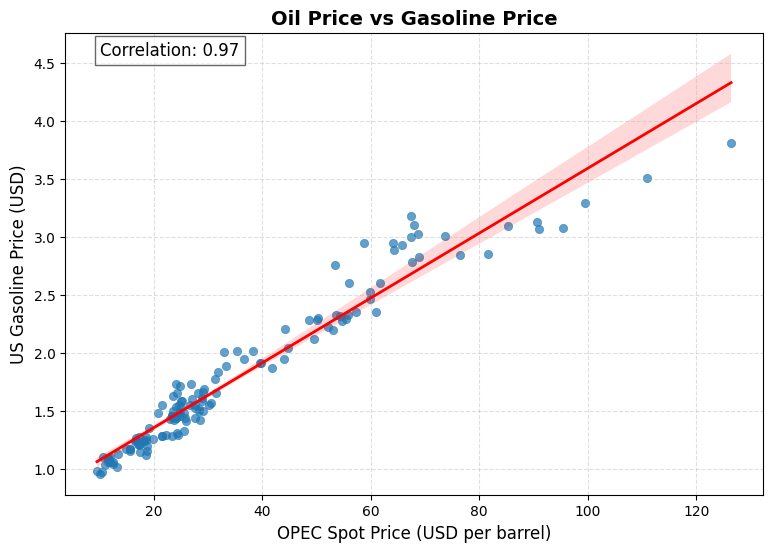

In [19]:


plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x='opec_spot_price_usd_per_barrel',
    y='us_gasoline_price_usd',
    alpha=0.7,  # makes overlap clearer
    edgecolor=None
)

# Add regression line for trend clarity
sns.regplot(
    data=df,
    x='opec_spot_price_usd_per_barrel',
    y='us_gasoline_price_usd',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2}
)

# Add grid for readability
plt.grid(True, linestyle='--', alpha=0.4)

# Titles and labels (clean + professional)
plt.title('Oil Price vs Gasoline Price', fontsize=14, fontweight='bold')
plt.xlabel('OPEC Spot Price (USD per barrel)', fontsize=12)
plt.ylabel('US Gasoline Price (USD)', fontsize=12)

# Add correlation text on plot
corr_value = df['opec_spot_price_usd_per_barrel'].corr(df['us_gasoline_price_usd'])

plt.text(
    0.05, 0.95,
    f'Correlation: {corr_value:.2f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.6)
)

plt.show()

In [39]:
df.columns

Index(['date', 'us_gasoline_price_usd', 'opec_spot_price_usd_per_barrel',
       'us_gasoline_production_1000_bpd',
       'us_natural_gas_price_usd_per_1000_cuft', 'month', 'year'],
      dtype='object')

In [21]:
df['month'].value_counts()

month
January      12
February     12
March        12
April        12
May          12
June         11
July         11
August       11
September    11
October      11
November     11
December     11
Name: count, dtype: int64

In [46]:
df.groupby("month")["us_gasoline_price_usd"].mean().sort_values(ascending=False).reset_index()

,month,us_gasoline_price_usd
0,May,1.995083
1,April,1.914167
2,September,1.840455
3,June,1.820273
4,August,1.812818
5,July,1.807545
6,March,1.802833
7,October,1.778091
8,November,1.732545
9,February,1.701583


In [22]:
gasoline_trend_by_year =df.groupby("year")["us_gasoline_price_usd"].mean().sort_values(ascending=False).reset_index()

In [23]:
gasoline_trend_by_year

,year,us_gasoline_price_usd
0,2008,3.357600
1,2007,2.845500
2,2006,2.615083
3,2005,2.312167
4,2004,1.891250
5,2003,1.601083
6,2000,1.524500
7,2001,1.466167
8,2002,1.381833
9,1997,1.245000


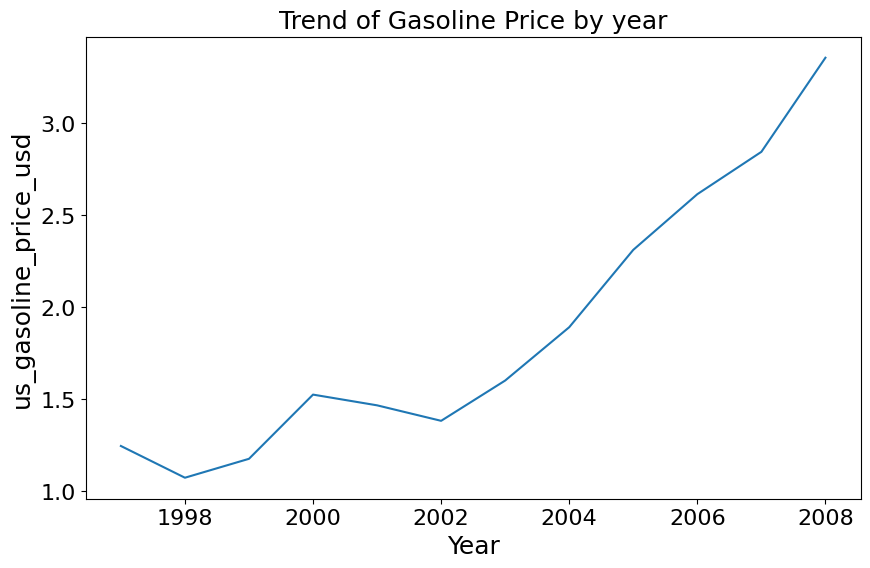

In [35]:
plt.figure(figsize=(10,6))
sns.lineplot(data=gasoline_trend_by_year,x="year",y="us_gasoline_price_usd")
plt.title("Trend of Gasoline Price by year",fontsize=18)
plt.xlabel("Year",fontsize=18)
plt.ylabel("us_gasoline_price_usd",fontsize=18)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
plt.show()

In [36]:
df.columns

Index(['date', 'us_gasoline_price_usd', 'opec_spot_price_usd_per_barrel',
       'us_gasoline_production_1000_bpd',
       'us_natural_gas_price_usd_per_1000_cuft', 'month', 'year'],
      dtype='object')

In [37]:
opec_price_trend_by_year =df.groupby("year")["opec_spot_price_usd_per_barrel"].mean().sort_values(ascending=False).reset_index()

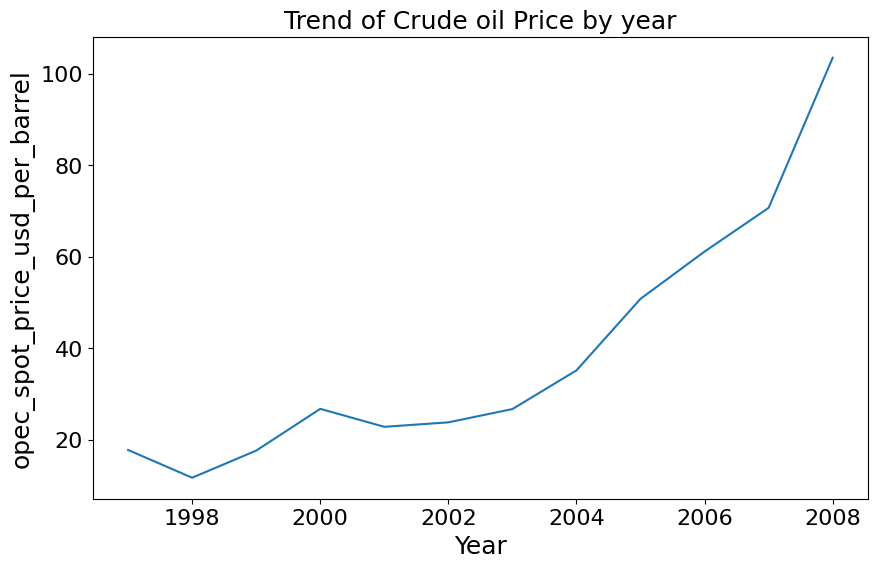

In [38]:
plt.figure(figsize=(10,6))
sns.lineplot(data=opec_price_trend_by_year,x="year",y="opec_spot_price_usd_per_barrel")
plt.title("Trend of Crude oil Price by year",fontsize=18)
plt.xlabel("Year",fontsize=18)
plt.ylabel("opec_spot_price_usd_per_barrel",fontsize=18)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
plt.show()

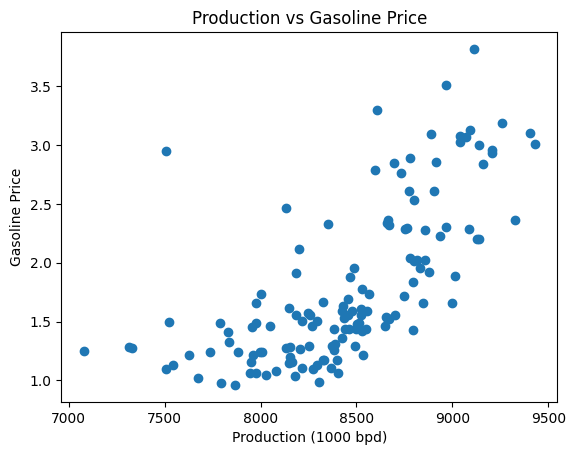

In [41]:
plt.figure()
plt.scatter(df['us_gasoline_production_1000_bpd'],
            df['us_gasoline_price_usd'])
plt.xlabel("Production (1000 bpd)")
plt.ylabel("Gasoline Price")
plt.title("Production vs Gasoline Price")
plt.show()

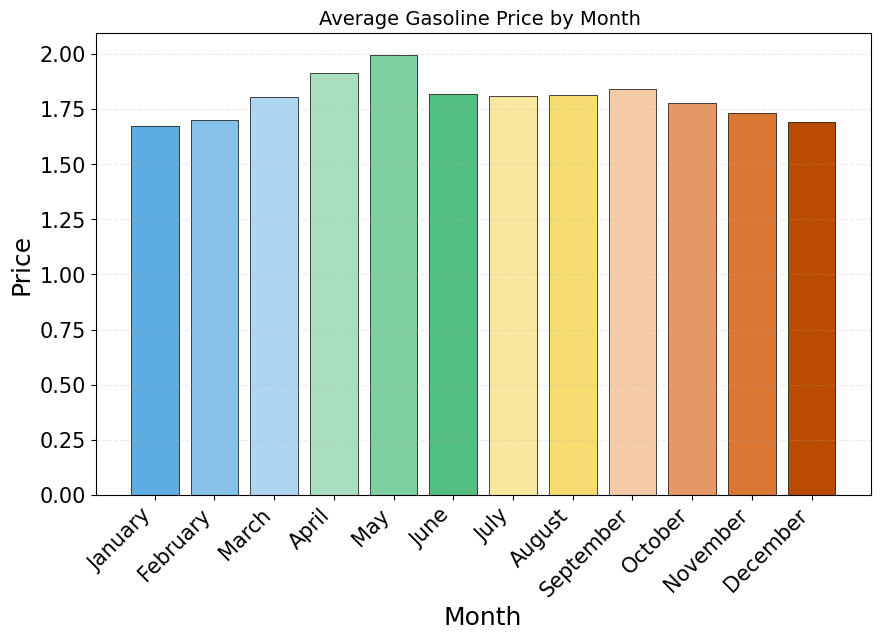

In [58]:


month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_avg = df.groupby('month')['us_gasoline_price_usd'].mean()
monthly_avg = monthly_avg.reindex(month_order)

# 
colors = [
    '#5DADE2', '#85C1E9', '#AED6F1',  # Jan–Mar (soft blues)
    '#A9DFBF', '#7DCEA0', '#52BE80',  # Apr–Jun (green transition)
    '#F9E79F', '#F7DC6F', '#F5CBA7',  # Jul–Sep (soft yellow/orange)
    '#E59866', '#DC7633', '#BA4A00'   # Oct–Dec (warm brown/orange)
]

plt.figure(figsize=(10,6))

plt.bar(month_order, monthly_avg, color=colors, edgecolor='black', linewidth=0.5)

plt.title("Average Gasoline Price by Month ", fontsize=14)
plt.xlabel("Month",fontsize=18)
plt.ylabel("Price",fontsize=18)
plt.xticks(rotation=45,ha='right',fontsize=15)
plt.yticks(fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.25)

plt.show()

In [59]:
df['opec_lag1'] = df['opec_spot_price_usd_per_barrel'].shift(1)

In [60]:
lag_df = df.dropna(subset=['opec_lag1', 'us_gasoline_price_usd'])

corr = lag_df[['us_gasoline_price_usd', 'opec_lag1']].corr()

print(corr)

                       us_gasoline_price_usd  opec_lag1
us_gasoline_price_usd               1.000000   0.976835
opec_lag1                           0.976835   1.000000


In [61]:
for i in range(1, 12):  # 1 to 6 months lag
    df[f'opec_lag{i}'] = df['opec_spot_price_usd_per_barrel'].shift(i)

# Check correlations
lag_corrs = {}

for i in range(1, 12):
    temp = df[['us_gasoline_price_usd', f'opec_lag{i}']].dropna()
    lag_corrs[f'lag_{i}'] = temp.corr().iloc[0, 1]

print(lag_corrs)

{'lag_1': np.float64(0.9768349642902503), 'lag_2': np.float64(0.9665200603099717), 'lag_3': np.float64(0.9535110217297097), 'lag_4': np.float64(0.9421046264225877), 'lag_5': np.float64(0.935384597085856), 'lag_6': np.float64(0.933018580755724), 'lag_7': np.float64(0.9297702700624981), 'lag_8': np.float64(0.9236657909209776), 'lag_9': np.float64(0.9178518425369373), 'lag_10': np.float64(0.9203302472831868), 'lag_11': np.float64(0.9225090800898392)}


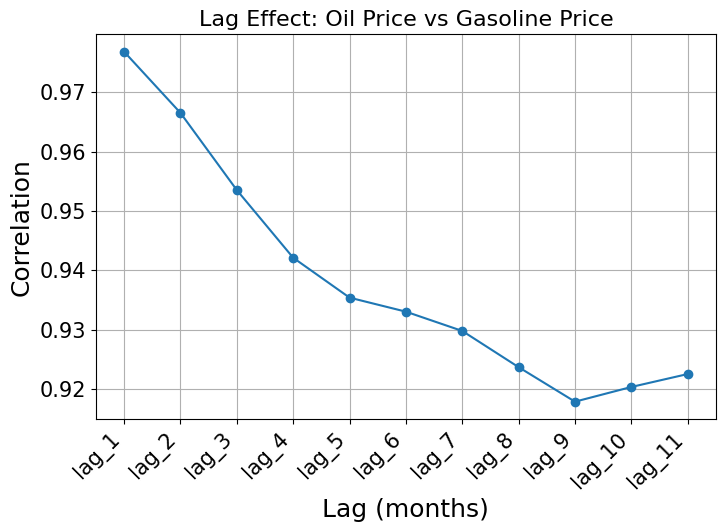

In [64]:
lags = list(lag_corrs.keys())
values = list(lag_corrs.values())

plt.figure(figsize=(8,5))
plt.plot(lags, values, marker='o')
plt.title("Lag Effect: Oil Price vs Gasoline Price",fontsize=16)
plt.xlabel("Lag (months)",fontsize=18)
plt.ylabel("Correlation",fontsize=18)
plt.xticks(rotation=45,ha='right',fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True)
plt.show()

#insights 
The analysis shows that global oil prices have a very strong and lasting impact on US gasoline prices. 
Changes in OPEC crude oil prices are reflected in gasoline prices within about one month, 
with the strongest effect occurring at this point.

Importantly, the influence of oil prices does not fade quickly.
Instead, it remains consistently strong for many months,
meaning that a single change in global oil markets can affect fuel prices over an extended period.

In [ ]:
#observations
